In [1]:
# pip install tensorflow
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt 

## chargement du dataset fashion

In [2]:
# Retourne 2 tuples : (image_train, labels_train) et (image_test, labels_test)
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

class_names = ["T-shirt", "Pantalon", "Pull", "Robe", "Manteau", "Sandale", "Chemise", "Sneaker", "Sac", "Bottine"]

print(f"Train set : {X_train.shape}")
print(f"Test set : {X_test.shape}")
# 0 = pixel noir, 255 = pixel blanc
print(f"valeurs pixels [{X_train.min()}, {X_train.max()}]")

Train set : (60000, 28, 28)
Test set : (10000, 28, 28)
valeurs pixels [0, 255]


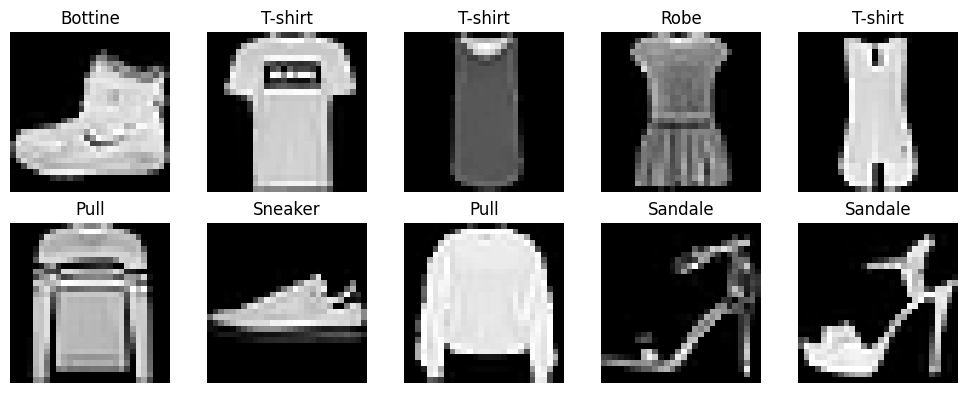

In [3]:
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"{class_names[y_train[i]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Preprocessing

In [4]:
# 1. Normalisation : divise par 255 pour ramener entre 0 et 1
X_train_norm = X_train.astype("float32") / 255.0
X_test_norm = X_test.astype("float32") / 255.0

# Aplatissement : (60000, 28, 28) => (60000, 784)
X_train_flat = X_train_norm.reshape(-1, 28*28)
X_test_flat = X_test_norm.reshape(-1, 28*28)

print(f"Train set : {X_train_flat.shape}")
print(f"Test set : {X_test_flat.shape}")

# classe 9 => [0,0,0,0,0,0,0,0,1,0]
y_train_onehot = keras.utils.to_categorical(y_train, num_classes=10)
y_test_onehot = keras.utils.to_categorical(y_test, num_classes=10)

print(y_train_onehot[0])

Train set : (60000, 784)
Test set : (10000, 784)
[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


## Création du modèle

- Total params : 109 386 = (784 * 128 + 128) + (128 * 64 + 64) + (64*10 + 10)
- couche 1 : 100 480 (poids + biais)

In [5]:
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(128, activation="relu", input_shape=(784,), name="hidden_1"),
    layers.Dense(64, activation="relu", name="hidden_2"),
    layers.Dense(10, activation="softmax", name="output")
], name="MLP_fashionMNIST")

model.summary()

c:\Users\Administrateur\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "MLP_fashionMNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## Configuration des paramètres d'entraînement

In [6]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

## Entrainement du modèle

In [7]:
tf.random.set_seed(42)

history = model.fit(
    X_train_flat, y_train_onehot,
    epochs=10, # lance l'entraînement 10 fois
    batch_size=128, # traite 128 exemple à la fois
    validation_split=0.1, # utilise 10% des données train pour la validation
    verbose=1,
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8083 - loss: 0.5539 - val_accuracy: 0.8500 - val_loss: 0.4215
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8601 - loss: 0.3908 - val_accuracy: 0.8593 - val_loss: 0.3845
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8736 - loss: 0.3501 - val_accuracy: 0.8647 - val_loss: 0.3742
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8829 - loss: 0.3238 - val_accuracy: 0.8698 - val_loss: 0.3626
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8881 - loss: 0.3055 - val_accuracy: 0.8720 - val_loss: 0.3547
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8934 - loss: 0.2888 - val_accuracy: 0.8750 - val_loss: 0.3450
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8985 - loss: 0.2755 - val_accuracy: 0.8810 - val_loss: 0.3352
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9025 - loss: 0.2633 - val_accuracy: 0.

## Graphique accuracy et loss

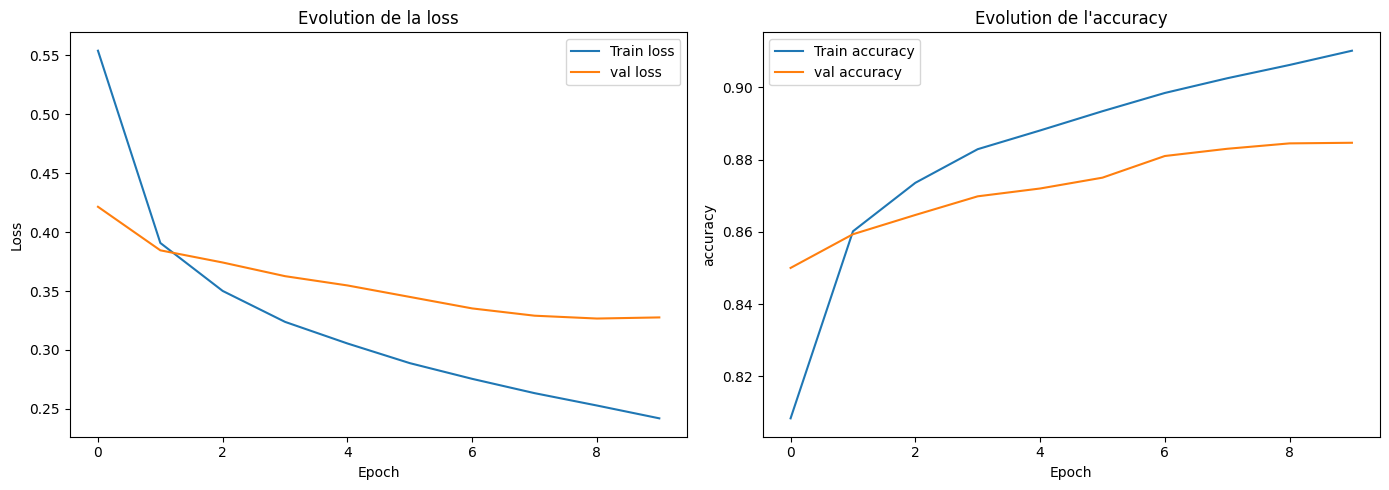

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# loss
ax1.plot(history.history["loss"], label="Train loss")
ax1.plot(history.history["val_loss"], label="val loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Evolution de la loss")
ax1.legend()

# Accuracy
ax2.plot(history.history["accuracy"], label="Train accuracy")
ax2.plot(history.history["val_accuracy"], label="val accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("accuracy")
ax2.set_title("Evolution de l'accuracy")
ax2.legend()

plt.tight_layout()
plt.show()

In [10]:
# Evaluer sur le test set
test_loss, test_accuracy = model.evaluate(X_test_flat, y_test_onehot, verbose=1)

print(f"Test loss : {test_loss}")
print(f"Test accuracy : {test_accuracy}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 839us/step - accuracy: 0.8765 - loss: 0.3513
Test loss : 0.3512600064277649
Test accuracy : 0.8765000104904175


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


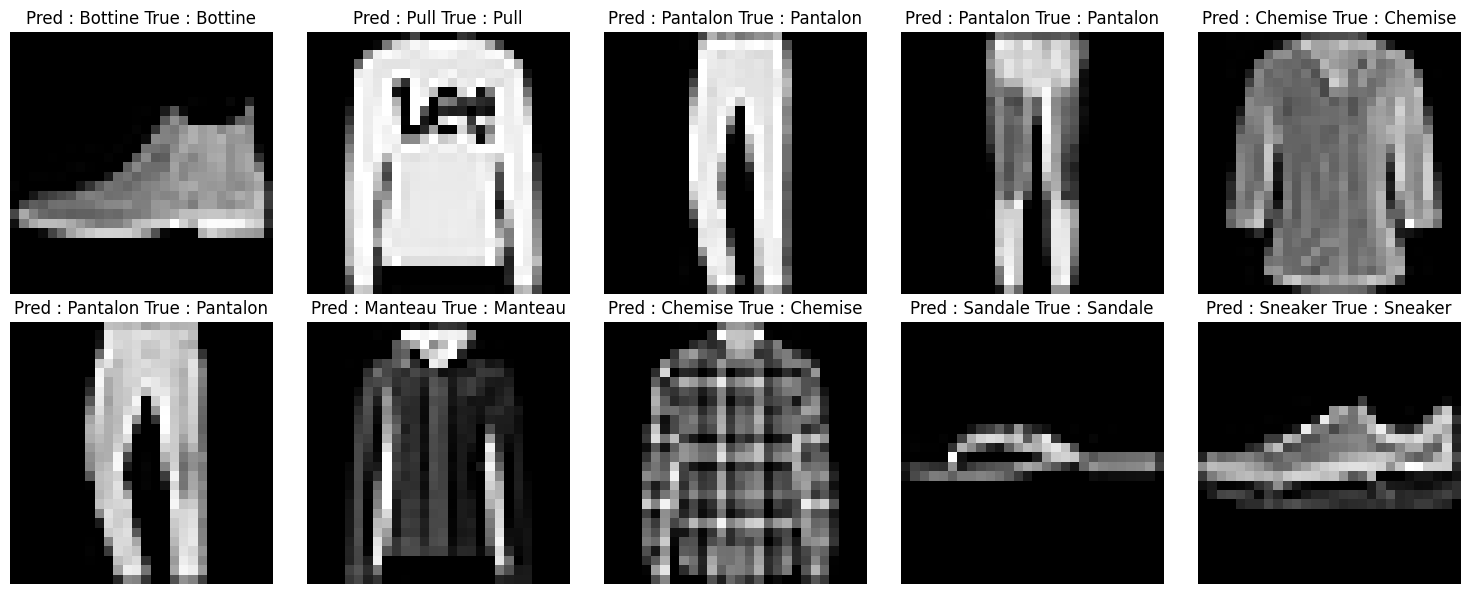

In [11]:
predictions = model.predict(X_test_flat[:10])
predicted_classes = np.argmax(predictions, axis=1)

plt.figure(figsize=(15,6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test[i], cmap="gray")
    plt.title(f"Pred : {class_names[predicted_classes[i]]} True : {class_names[y_test[i]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

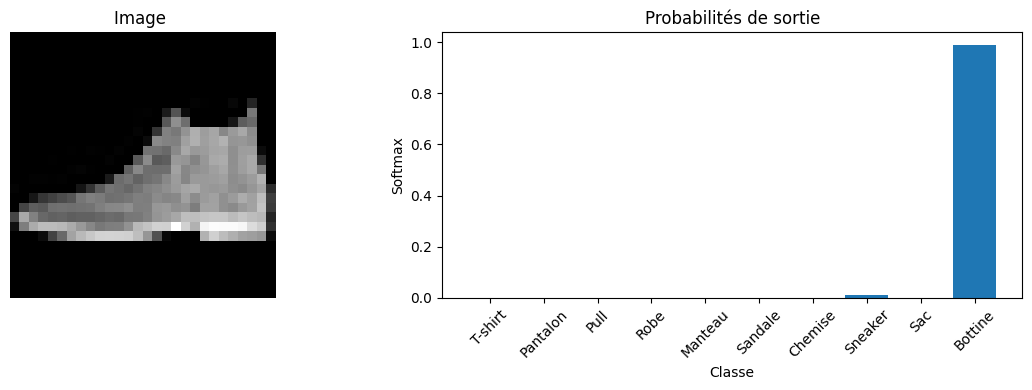

In [13]:
idx = 0
sample_prediction = predictions[idx]

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,4))

ax1.imshow(X_test[idx], cmap="gray")
ax1.set_title("Image ")
ax1.axis("off")

ax2.bar(range(10), sample_prediction)
ax2.set_xlabel("Classe")
ax2.set_ylabel("Softmax")
ax2.set_title("Probabilités de sortie")
ax2.set_xticks(range(10))
ax2.set_xticklabels(class_names, rotation=45)

plt.tight_layout()
plt.show()

In [15]:
for i, prob in enumerate(sample_prediction):
    print(f"{class_names[i]}  : {prob*100:2f}%")

T-shirt  : 0.000247%
Pantalon  : 0.000000%
Pull  : 0.000085%
Robe  : 0.000356%
Manteau  : 0.000135%
Sandale  : 0.089262%
Chemise  : 0.000829%
Sneaker  : 0.984502%
Sac  : 0.000062%
Bottine  : 98.924530%
